# Exploring soil modeling in soilice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice.src_soil import model

In [3]:
from matplotlib.gridspec import GridSpec

In [4]:
def pf_plot(out):
    
    t,dt,psie1,T1,thetaL1,thetaI1,qI,qT1,qB1,jT1,jB = (
        out.t,
        out.dt,
        out.psie,
        out.T,
        out.thetaL,
        out.thetaI,
        out.qI,
        out.qT,
        out.qB,
        out.jT,
        out.jB
    )
    start=-365
    pl.subplot(2,1,1)
    pl.plot(t[start:]-t[start],qI[start:]*1000,'.-',label='Potential infiltration') 
    pl.plot(t[start:]-t[start],qT1[start:]/dt*1000,label='Actual infiltration')
    pl.plot(t[start:]-t[start],qB1[start:]/dt*1000,label='Drainage')
    pl.legend()
    pl.grid()
    pl.ylim(0,15)
    pl.xlim(0,365)
    pl.subplot(2,1,2)
    pl.plot(np.nan,np.nan,'-k',label='Zero degree isotherm')
    cf=pl.contourf(t[start:]-t[start],z,thetaI1[start:,:].T,np.arange(0.025,0.45,0.025),cmap='Blues')
    pl.contour(t[start:]-t[start],z,T1[start:,:].T,[0],colors='k')
    pl.legend(loc=4)
    cbar = pl.colorbar(cf,orientation='horizontal', fraction=0.1, pad=0.08)
    cbar.set_label('Ice content')
    pl.grid()
    pl.ylim(2,0)
    pl.xlim(0,365)
    pl.gca().set_xticklabels('')

In [5]:
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=1.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=1.          # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=1.     # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=1.          # 0. no flow lower BC, 1.0 free draining lowerBC

In [6]:
# Space grid
zMax=2.
dz=0.02
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

In [7]:
sim=model(opts,rtol=1e-8)
sim.zGrid(np.hstack([0,np.cumsum(dz)]))
sim.tGrid(0,365*4,1)
# sim.pars=pars
# sim.const=const
sim.readPars()

In [8]:
sim.printOpts()

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * Solving correct mass bal eqns
     * Vertical flow
     * No cryosuction
     * Included heat advection
     * No conduction on the upper boundary
     * Conduction on the lower boundary
     * Simulating flow
     * Simulating heat transport
     * Free draining lower boundary condition
*************************************************************************



In [9]:
# Run scenarios with different boundary/initial conditions
# Boundary conditions - mass and heat fluxes:
jTopBC=np.sin(sim.t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.
sim.setBCs(TBot=-1,jTopBC=jTopBC)

sim.setICs(psi0=-1,T0=[0.25,-1])

out=sim.run()

*************************************************************************
     soilice ran successfully!
               runtime:      12.20 seconds
     Mass balance rmse:  6.05e-04 kg
                  bias: -1.05e-03 kg
   Energy balance rmse:  1.84e+02 J
                  bias:  3.32e+02 J
*************************************************************************



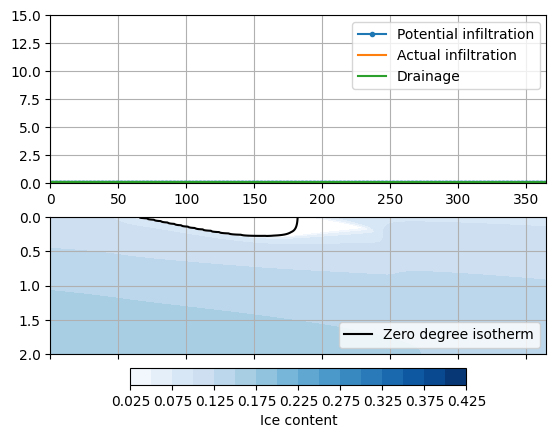

In [10]:
pf_plot(out)
pl.savefig('figures/06_PFS_01.png')

In [11]:
# Run scenarios with different boundary/initial conditions
# Boundary conditions - mass and heat fluxes:
qI=np.zeros(sim.nt)+0.0005
qI[(sim.t%365>30)&(sim.t%365<60)]=0.005
TInf=np.zeros(sim.nt)+5
TInf[(sim.t%365>30)&(sim.t%365<60)]=0.
jTopBC=np.sin(sim.t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.
sim.setBCs(qI=qI,TInf=TInf,TBot=-1,jTopBC=jTopBC)
sim.setICs(psi0=-2,T0=[0.25,-1])

out2=sim.run()

/Users/ani378/pyenvs/3-12/lib/python3.12/site-packages/scipy/integrate/_ode.py:431: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


*************************************************************************
     soilice ran successfully!
               runtime:      15.26 seconds
     Mass balance rmse:  2.45e+02 kg
                  bias:  4.88e+02 kg
   Energy balance rmse:  8.20e+07 J
                  bias: -1.63e+08 J
*************************************************************************



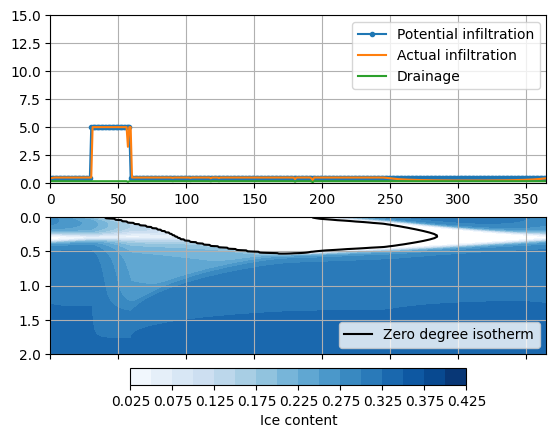

In [12]:
pf_plot(out2)
pl.savefig('figures/06_PFS_02.png')

In [13]:
# Run scenarios with different boundary/initial conditions
# Boundary conditions - mass and heat fluxes:
qI=np.zeros(sim.nt)+0.0005
qI[(sim.t%365>0)&(sim.t%365<30)]=0.005
TInf=np.zeros(sim.nt)+5
TInf[(sim.t%365>0)&(sim.t%365<30)]=0.
jTopBC=np.sin(sim.t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.
sim.setBCs(qI=qI,TInf=TInf,TBot=-1,jTopBC=jTopBC)
sim.setICs(psi0=-2,T0=[-1,-1])

out3=sim.run()

/Users/ani378/pyenvs/3-12/lib/python3.12/site-packages/scipy/integrate/_ode.py:431: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


*************************************************************************
     soilice ran successfully!
               runtime:      11.62 seconds
     Mass balance rmse:  1.16e+02 kg
                  bias:  2.16e+02 kg
   Energy balance rmse:  3.88e+07 J
                  bias: -7.23e+07 J
*************************************************************************



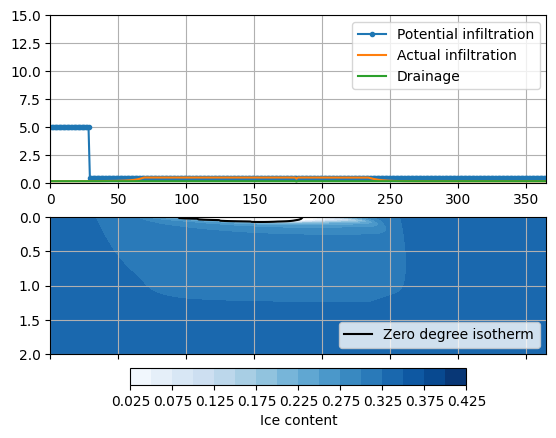

In [14]:
pf_plot(out3)
pl.savefig('figures/06_PFS_03.png')